# Домашнее задание к семинару 07 (HW07)
## Тема: кластеризация, внутренние метрики качества, PCA/t-SNE и "честный" unsupervised-эксперимент на синтетических данных.

## Испорты и константы

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
pca_dim = 10

kmeans_ks = list(range(2, 21))

dbscan_eps = [1.5, 2.0, 2.5, 3.0, 3.5]
dbscan_min_samples = [3, 5, 10]

agg_ks = list(range(2, 21))
agg_linkages = ["ward", "complete", "average"]

## Функции для работы

### Визуализация

In [ ]:
def corr_heat(df: pd.DataFrame):
    corr = df.select_dtypes("number").corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, square=True, linewidths=.5)
    plt.title("Pearson correlation")
    plt.show()

In [4]:
def outlier_strip(df: pd.DataFrame, top_n: int = 8):
    """Box + поверх strip всех точек – визуально видны выбросы."""
    cols = df.select_dtypes("number").columns[:top_n]
    plt.figure(figsize=(top_n*2, 4))
    sns.boxplot(data=df[cols], orient="h", palette="Set2", width=.5)
    sns.stripplot(data=df[cols], orient="h", color=".25", size=2, alpha=.4)
    plt.title("Outliers: box + strip")
    plt.show()


In [5]:
def pca_2d_for_plot(X_scaled, random_state=RANDOM_STATE):
    """PCA(2D) именно для визуализации."""
    p = PCA(n_components=2, random_state=random_state)
    return p.fit_transform(X_scaled)

def plot_2d_embedding(emb2d, labels, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(emb2d[:, 0], emb2d[:, 1], c=labels, s=18)
    plt.title(title)
    plt.xlabel("dim-1")
    plt.ylabel("dim-2")
    plt.grid(True, alpha=0.2)
    plt.show()

def summarize_labels(labels):
    unique, counts = np.unique(labels, return_counts=True)
    return dict(zip(unique.tolist(), counts.tolist()))


### Метрики

In [6]:
def safe_cluster_metrics(X, labels):
    """Считает метрики; возвращает None, если метрика неприменима."""
    unique = np.unique(labels)
    # Нужно минимум 2 кластера
    if len(unique) < 2:
        return None

    # Нельзя, чтобы все точки были в одном кластере
    if len(unique) == 1:
        return None

    # silhouette требует, чтобы все кластеры имели >1 точки (часто, но не всегда)
    # В sklearn silhouette_score может падать, если какой-то кластер пуст/особый.
    try:
        sil = float(silhouette_score(X, labels))
    except Exception:
        sil = None

    try:
        db = float(davies_bouldin_score(X, labels))
    except Exception:
        db = None

    try:
        ch = float(calinski_harabasz_score(X, labels))
    except Exception:
        ch = None

    return {"silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch}

In [7]:
def pick_best_by_silhouette(results):
    best = None
    best_score = -np.inf
    for r in results:
        m = r["metrics"]
        if m is None:
            continue
        s = m["silhouette"]
        if s is None:
            continue
        if s > best_score:
            best_score = s
            best = r
    return best, best_score

In [8]:
def print_result_card(name, result):
    m = result["metrics"] or {}
    print("=" * 72)
    print(f"{name}")
    print("algo:", result["algo"])
    print("params:", result["params"])
    print("n_clusters:", result.get("n_clusters"))
    if result["algo"] == "dbscan":
        print("noise_frac:", round(result.get("noise_frac", 0.0), 3), " non-noise:", result.get("n_non_noise"))
    print("metrics:")
    print("  silhouette:", None if m.get("silhouette") is None else round(m["silhouette"], 3))
    print("  davies_bouldin:", None if m.get("davies_bouldin") is None else round(m["davies_bouldin"], 3))
    print("  calinski_harabasz:", None if m.get("calinski_harabasz") is None else round(m["calinski_harabasz"], 1))
    if result.get("inertia") is not None:
        print("  inertia:", round(result["inertia"], 1))

### Реализация алгоритмов кластеризации

In [9]:
def eval_kmeans_grid(X_feat, ks):
    results = []
    for k in ks:
        try:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        except TypeError:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)

        labels = model.fit_predict(X_feat)
        metrics = safe_cluster_metrics(X_feat, labels)

        results.append({
            "algo": "kmeans",
            "params": {"k": k},
            "labels": labels,
            "metrics": metrics,
            "inertia": float(model.inertia_),
            "n_clusters": len(np.unique(labels)),
            "noise_frac": 0.0,
        })
    return results


In [10]:
def eval_dbscan_grid(X_feat, eps_list, min_samples_list):
    results = []
    n = len(X_feat)

    for eps in eps_list:
        for ms in min_samples_list:
            model = DBSCAN(eps=eps, min_samples=ms)
            labels = model.fit_predict(X_feat)

            noise_frac = float(np.mean(labels == -1))
            # Метрики по non-noise
            mask = labels != -1
            labels_nn = labels[mask]
            X_nn = X_feat[mask]

            # Перенумеруем метки non-noise, чтобы метрики работали корректнее (не обязательно, но аккуратно)
            if len(labels_nn) > 0:
                uniq = np.unique(labels_nn)
                mapping = {u: i for i, u in enumerate(uniq)}
                labels_nn = np.array([mapping[v] for v in labels_nn], dtype=int)

            metrics = None
            n_clusters = 0
            if len(X_nn) >= 10 and len(np.unique(labels_nn)) >= 2:
                metrics = safe_cluster_metrics(X_nn, labels_nn)
                n_clusters = len(np.unique(labels_nn))

            results.append({
                "algo": "dbscan",
                "params": {"eps": float(eps), "min_samples": int(ms)},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": int(n_clusters),
                "noise_frac": float(noise_frac),
                "n_non_noise": int(mask.sum()),
            })
    return results

In [11]:
def eval_agglomerative_grid(X_feat, ks, linkages):
    results = []
    for linkage_name in linkages:
        for k in ks:
            try:
                model = AgglomerativeClustering(n_clusters=k, linkage=linkage_name)
                labels = model.fit_predict(X_feat)
            except Exception:
                continue

            metrics = safe_cluster_metrics(X_feat, labels)

            results.append({
                "algo": "agglomerative",
                "params": {"k": int(k), "linkage": linkage_name},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": len(np.unique(labels)),
                "noise_frac": 0.0,
            })
    return results

### Препроцессинг

In [12]:
def get_pipeline(X):
    return Pipeline([
    ('scaler' , StandardScaler()),
    ('PCA' , PCA(n_components=min(pca_dim,X.shape[1]),random_state=RANDOM_STATE))
    ]
)

# S07-hw-dataset-01.csv

##  Загрузка и EDA

In [13]:
df1 = pd.read_csv('data/S07-hw-dataset-01.csv')
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


In [14]:
df1.head()

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


In [15]:
X = df1.drop(columns=["sample_id"])
sample_id = df1['sample_id']

In [16]:
X.select_dtypes('number').shape[1]

8

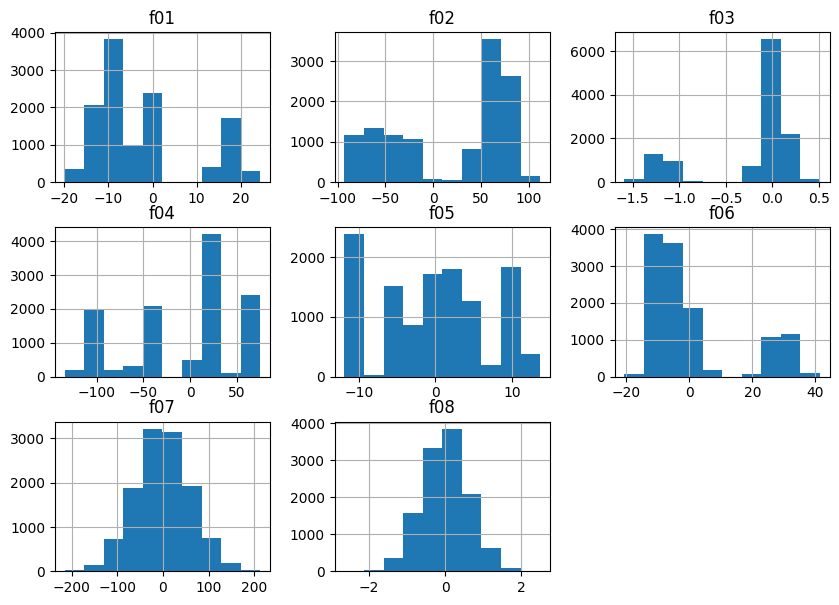

In [17]:
X.hist(figsize=(10,7));

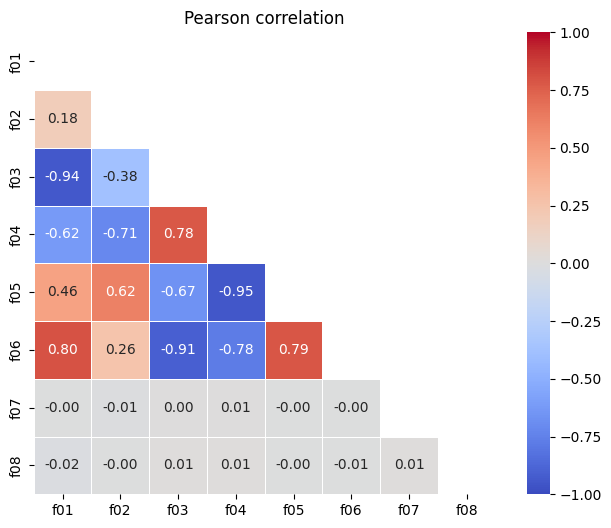

In [18]:
corr_heat(X)

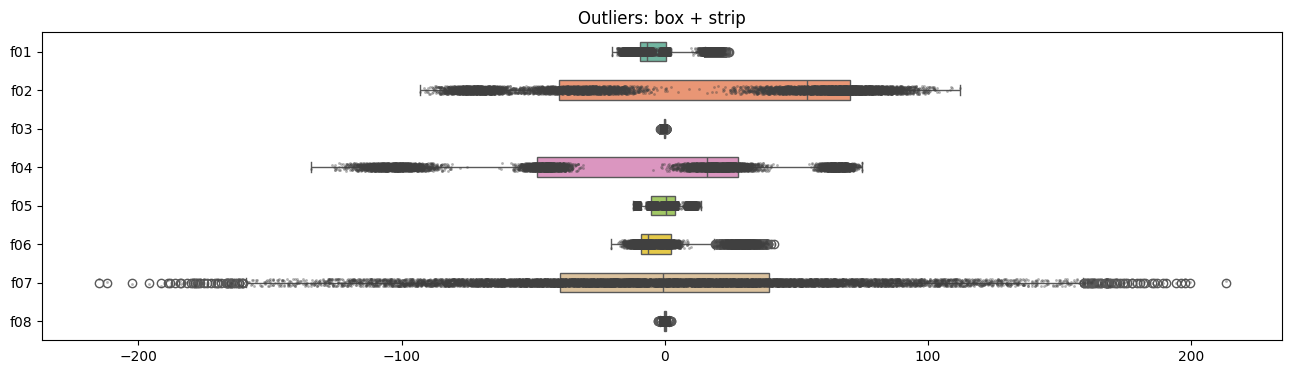

In [19]:
outlier_strip(X,top_n=X.shape[1])

## Препроцессинг

In [20]:
pipeline_data = get_pipeline(X)
X_scaled = pipeline_data.fit_transform(X)

    Выбросов и категориальных признаков в данных нет, поэтому только отмасштабировали

## Модели недели 7


### k-means

In [21]:
kmeans_results = eval_kmeans_grid(X_scaled, kmeans_ks)
len(kmeans_results), kmeans_results[0]["params"], kmeans_results[-1]["params"]

(19, {'k': 2}, {'k': 20})

In [22]:
best_kmeans, best_kmeans_s = pick_best_by_silhouette(kmeans_results)
best_kmeans["params"], round(best_kmeans_s, 3)

({'k': 2}, 0.522)

### DBSCAN

In [23]:
dbscan_results = eval_dbscan_grid(X_scaled, dbscan_eps, dbscan_min_samples)
len(dbscan_results)

15

In [24]:
valid = [r for r in dbscan_results if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
valid_sorted = sorted(valid, key=lambda r: r["metrics"]["silhouette"], reverse=True)

best_dbscan = valid_sorted[0] if valid_sorted else None
best_dbscan["params"] if best_dbscan else "No valid config found"

{'eps': 2.0, 'min_samples': 3}

### AgglomerativeClustering

In [25]:
agg_results = eval_agglomerative_grid(X_scaled, agg_ks, agg_linkages)
len(agg_results), agg_results[0]["params"]

(57, {'k': 2, 'linkage': 'ward'})

In [26]:
best_agg, best_agg_s = pick_best_by_silhouette(agg_results)
best_agg["params"], round(best_agg_s, 3)

({'k': 2, 'linkage': 'ward'}, 0.522)

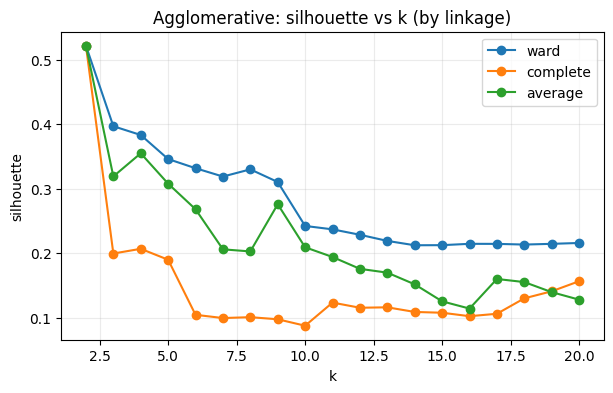

In [27]:
plt.figure(figsize=(7, 4))

for linkage_name in agg_linkages:
    subset = [r for r in agg_results if r["params"]["linkage"] == linkage_name]
    subset = sorted(subset, key=lambda r: r["params"]["k"])
    ks = [r["params"]["k"] for r in subset]
    sil = [r["metrics"]["silhouette"] if r["metrics"] else None for r in subset]
    plt.plot(ks, sil, marker="o", label=linkage_name)

plt.title("Agglomerative: silhouette vs k (by linkage)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()


###  Выбор лучших и визуализация

In [28]:
print_result_card("BEST KMEANS (by silhouette)", best_kmeans)
if best_dbscan is not None:
    print_result_card("BEST DBSCAN (by silhouette among valid)", best_dbscan)
print_result_card("BEST AGGLOMERATIVE (by silhouette)", best_agg)

BEST KMEANS (by silhouette)
algo: kmeans
params: {'k': 2}
n_clusters: 2
metrics:
  silhouette: 0.522
  davies_bouldin: 0.685
  calinski_harabasz: 11787.0
  inertia: 48425.9
BEST DBSCAN (by silhouette among valid)
algo: dbscan
params: {'eps': 2.0, 'min_samples': 3}
n_clusters: 2
noise_frac: 0.0  non-noise: 12000
metrics:
  silhouette: 0.522
  davies_bouldin: 0.685
  calinski_harabasz: 11787.0
BEST AGGLOMERATIVE (by silhouette)
algo: agglomerative
params: {'k': 2, 'linkage': 'ward'}
n_clusters: 2
metrics:
  silhouette: 0.522
  davies_bouldin: 0.685
  calinski_harabasz: 11787.0


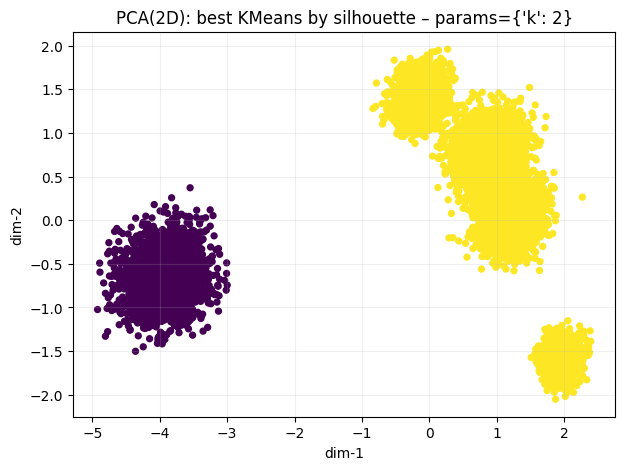

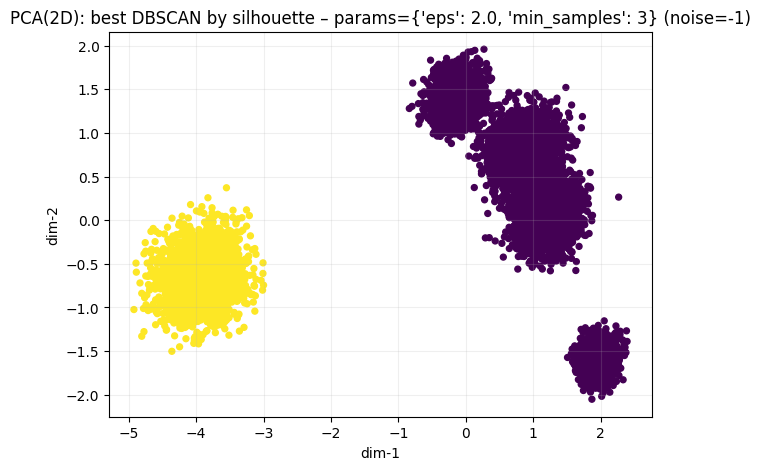

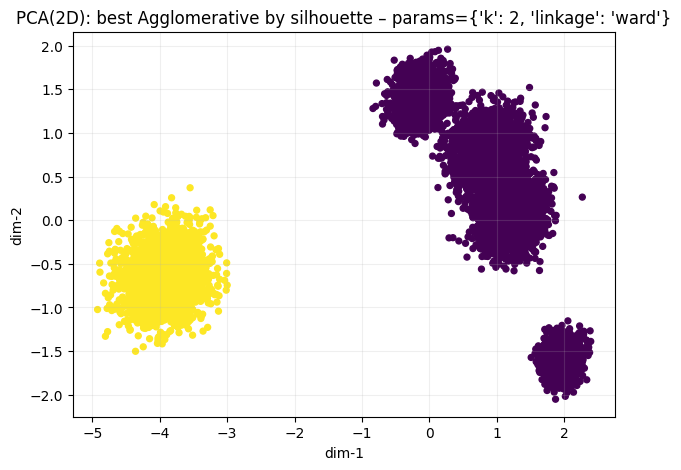

In [29]:
X_plot2d = pca_2d_for_plot(X_scaled, random_state=RANDOM_STATE)

# KMeans best
plot_2d_embedding(
    X_plot2d, best_kmeans["labels"],
    title=f"PCA(2D): best KMeans by silhouette – params={best_kmeans['params']}"
)

# DBSCAN best (if exists)
if best_dbscan is not None:
    plot_2d_embedding(
        X_plot2d, best_dbscan["labels"],
        title=f"PCA(2D): best DBSCAN by silhouette – params={best_dbscan['params']} (noise=-1)"
    )

# Agglomerative best
plot_2d_embedding(
    X_plot2d, best_agg["labels"],
    title=f"PCA(2D): best Agglomerative by silhouette – params={best_agg['params']}"
)


    Как видим, кластеры примерно одинаковые и все методы поделили на 2 кластера одинаковым способом.

# S07-hw-dataset-02.csv

##  Загрузка и EDA

In [30]:
df2 = pd.read_csv('data/S07-hw-dataset-02.csv')
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB


In [31]:
df2.describe()

,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076


In [32]:
X = df2.drop(columns=['sample_id'])

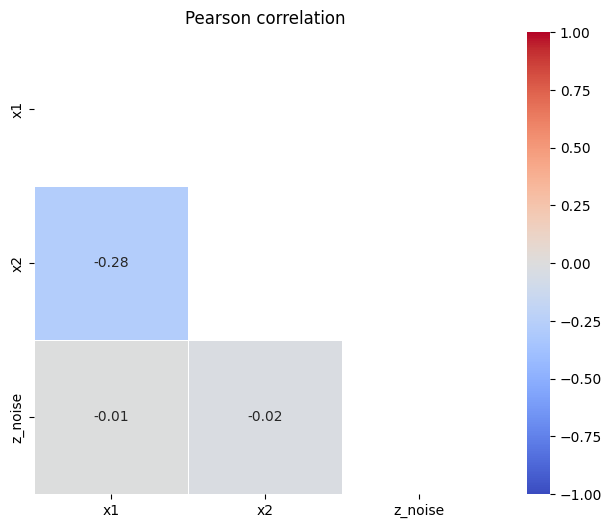

In [33]:
corr_heat(X)

    Видно, что шумный признак имеет низкую корреляцию с другими признаками. (в районе одной сотой)

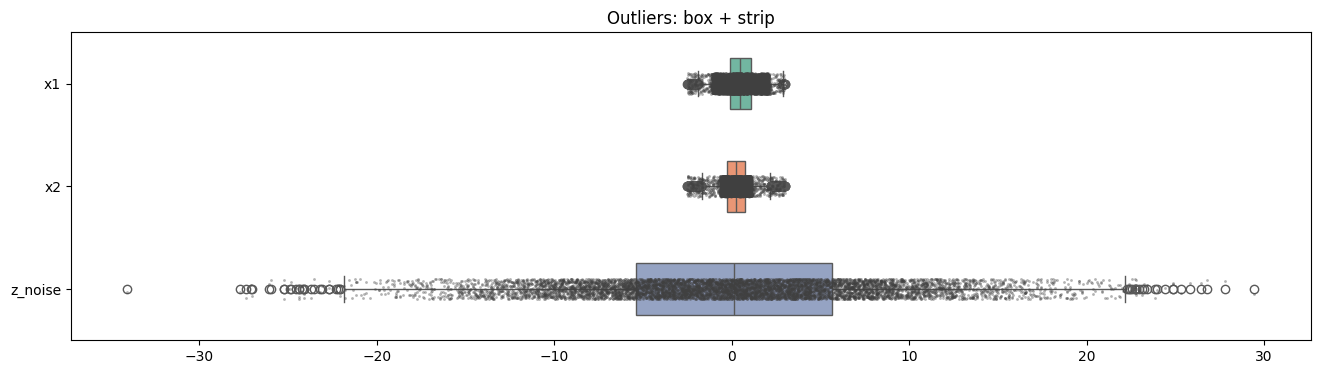

In [34]:
outlier_strip(X)

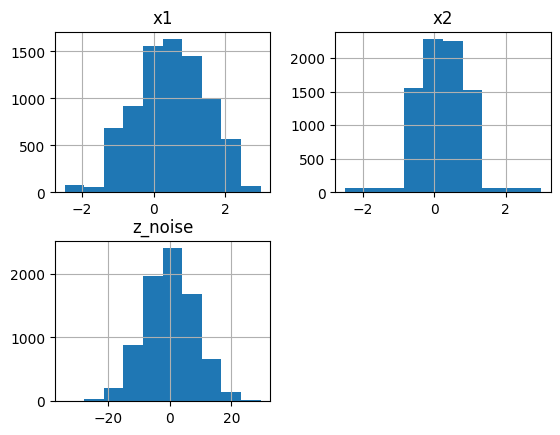

In [35]:
X.hist();

In [36]:
var = X['z_noise'].var()
cv = X['z_noise'].std() / abs(X['z_noise'].mean())
print(f"Дисперсия: {var:.3f}, CV: {cv:.3f}")

Дисперсия: 65.573, CV: 73.313


    Видно, что у признака очень высокая дисперсия и коллосальный коэффициент вариации (73 %). Удалим его.

##  Препроцессинг

In [37]:
X = X.drop(columns=['z_noise'])

In [38]:
pipeline = get_pipeline(X)
X_scaled = pipeline.fit_transform(X)

## Модели недели 7

### k-means

In [39]:
kmeans_results = eval_kmeans_grid(X_scaled, kmeans_ks)
len(kmeans_results), kmeans_results[0]["params"], kmeans_results[-1]["params"]

(19, {'k': 2}, {'k': 20})

In [40]:
best_kmeans, best_kmeans_s = pick_best_by_silhouette(kmeans_results)
best_kmeans["params"], round(best_kmeans_s, 3)

({'k': 13}, 0.467)

### DBSCAN

In [41]:
dbscan_results = eval_dbscan_grid(X_scaled, dbscan_eps, dbscan_min_samples)
len(dbscan_results)

15

In [42]:
valid = [r for r in dbscan_results if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
valid_sorted = sorted(valid, key=lambda r: r["metrics"]["silhouette"], reverse=True)

best_dbscan = valid_sorted[0] if valid_sorted else None
best_dbscan["params"] if best_dbscan else "No valid config found"

'No valid config found'

### AgglomerativeClustering

In [43]:
agg_results = eval_agglomerative_grid(X_scaled, agg_ks, agg_linkages)
len(agg_results), agg_results[0]["params"]

(57, {'k': 2, 'linkage': 'ward'})

In [44]:
best_agg, best_agg_s = pick_best_by_silhouette(agg_results)
best_agg["params"], round(best_agg_s, 3)

({'k': 2, 'linkage': 'average'}, 0.507)

### Выбор лучшего метода и визуализация

In [45]:
print_result_card("BEST KMEANS (by silhouette)", best_kmeans)
if best_dbscan is not None:
    print_result_card("BEST DBSCAN (by silhouette among valid)", best_dbscan)
print_result_card("BEST AGGLOMERATIVE (by silhouette)", best_agg)

BEST KMEANS (by silhouette)
algo: kmeans
params: {'k': 13}
n_clusters: 13
metrics:
  silhouette: 0.467
  davies_bouldin: 0.634
  calinski_harabasz: 7772.9
  inertia: 1262.0
BEST AGGLOMERATIVE (by silhouette)
algo: agglomerative
params: {'k': 2, 'linkage': 'average'}
n_clusters: 2
metrics:
  silhouette: 0.507
  davies_bouldin: 0.751
  calinski_harabasz: 628.8


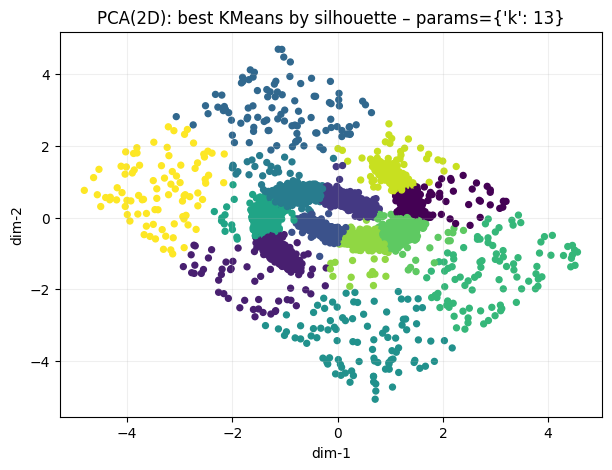

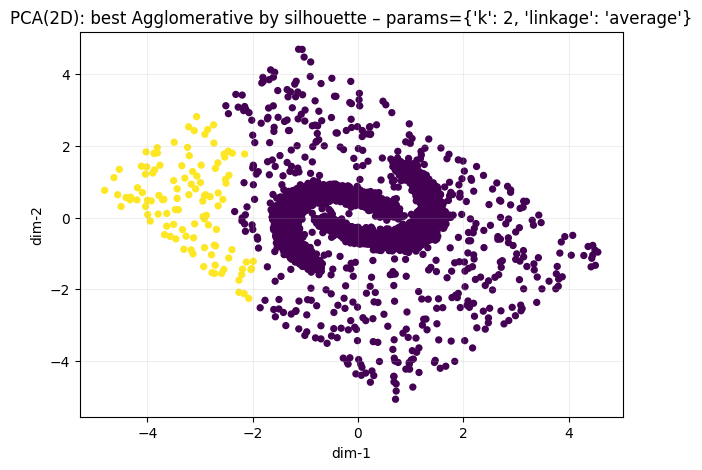

In [46]:
X_plot_2d = pca_2d_for_plot(X_scaled, random_state=RANDOM_STATE)

# KMeans best
plot_2d_embedding(
    X_plot_2d, best_kmeans["labels"],
    title=f"PCA(2D): best KMeans by silhouette – params={best_kmeans['params']}"
)

# DBSCAN best (if exists)
if best_dbscan is not None:
    plot_2d_embedding(
        X_plot_2d, best_dbscan["labels"],
        title=f"PCA(2D): best DBSCAN by silhouette – params={best_dbscan['params']} (noise=-1)"
    )

# Agglomerative best
plot_2d_embedding(
    X_plot_2d, best_agg["labels"],
    title=f"PCA(2D): best Agglomerative by silhouette – params={best_agg['params']}"
)


# S07-hw-dataset-04.csv

##  Загрузка и EDA

In [47]:
df4 = pd.read_csv('data/S07-hw-dataset-04.csv')
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  10000 non-null  int64  
 1   cat_a      10000 non-null  object 
 2   cat_b      10000 non-null  object 
 3   n01        9826 non-null   float64
 4   n02        9811 non-null   float64
 5   n03        9801 non-null   float64
 6   n04        9808 non-null   float64
 7   n05        9799 non-null   float64
 8   n06        9817 non-null   float64
 9   n07        9796 non-null   float64
 10  n08        9806 non-null   float64
 11  n09        9805 non-null   float64
 12  n10        9811 non-null   float64
 13  n11        9796 non-null   float64
 14  n12        9798 non-null   float64
 15  n13        9803 non-null   float64
 16  n14        9802 non-null   float64
 17  n15        9814 non-null   float64
 18  n16        9809 non-null   float64
 19  n17        9788 non-null   float64
 20  n18    

In [48]:
df4.head()

,sample_id,cat_a,cat_b,n01,n02,n03,n04,n05,n06,n07,...,n21,n22,n23,n24,n25,n26,n27,n28,n29,n30
0,0,B,X,-4.827501,-24.507466,-7.852963,0.771781,28.297884,-4.493911,-42.769449,...,24.597176,-26.354320,4.543397,-19.549036,-3.051332,-5.538587,-3.084457,5.499629,-6.128896,3.132067
1,1,F,V,51.302500,NaN,5.534737,51.305464,-8.027553,28.297548,NaN,...,-18.216260,8.527932,17.202115,-30.452260,0.855326,1.199066,3.597555,-2.239703,2.932710,0.473145
2,2,A,W,-4.820828,-2.625385,27.891578,1.523041,-5.776687,-16.298523,2.462937,...,-48.260775,9.313232,12.323411,55.081325,-3.945606,-0.280540,-0.130583,-7.353205,-2.942836,1.460477
3,3,B,X,-2.627573,-25.063639,-9.450011,-8.344669,22.371118,-11.525848,-43.762607,...,24.700663,-25.466915,-3.398665,-18.174541,0.438229,3.152556,3.859283,-2.678769,-2.213923,-4.724639
4,4,C,Y,-11.415710,-8.692169,48.636163,14.661826,-39.634618,10.769075,40.187536,...,-79.710383,-13.694253,41.575892,-9.498640,1.529608,-1.641347,3.500090,3.111257,1.475232,-1.321676


In [51]:
X = df4.drop(columns=['sample_id'])

In [52]:
X.describe()

,n01,n02,n03,n04,n05,n06,n07,n08,n09,n10,...,n21,n22,n23,n24,n25,n26,n27,n28,n29,n30
count,9826.000000,9811.000000,9801.000000,9808.000000,9799.000000,9817.000000,9796.000000,9806.000000,9805.000000,9811.000000,...,9785.000000,9804.000000,9829.000000,9793.000000,9815.000000,9776.000000,9803.000000,9789.000000,9798.000000,9805.000000
mean,17.348435,-2.057620,7.908302,14.269157,0.900590,5.832787,-0.840875,-4.888128,3.184200,1.591623,...,-12.716502,-0.506241,8.360226,0.026943,0.039297,-0.037155,0.028512,-0.030738,-0.018685,-0.030254
std,22.578551,19.043410,25.637807,18.815319,20.981294,13.221646,26.583849,15.466271,32.208740,18.579496,...,37.290305,14.336833,17.754646,26.121335,3.009995,3.020813,3.028106,3.000090,3.014209,3.014573
min,-22.437090,-37.546998,-38.136412,-23.374316,-45.914070,-20.650038,-60.297304,-44.464550,-70.904880,-46.689667,...,-89.640783,-35.102360,-25.014050,-49.423300,-11.225848,-14.446922,-10.840777,-11.679259,-11.437909,-11.491223
25%,-3.975438,-14.200552,-8.591513,-1.223379,-5.086756,-4.532057,-13.554720,-17.352641,-11.460490,-2.287358,...,-41.284671,-11.563652,-2.123576,-19.425213,-1.973213,-2.082235,-2.007628,-2.074500,-2.051778,-2.074396
50%,22.042807,-6.532183,0.350400,10.069142,2.413111,7.391953,-2.429024,-7.095546,13.258691,3.689919,...,-1.145681,2.491416,6.691365,-8.464171,0.037806,-0.033336,0.031588,-0.043127,-0.015441,-0.015903
75%,37.535647,2.092197,30.725630,29.807101,18.398883,13.033076,16.095731,3.909111,20.188426,13.525235,...,18.916379,11.903004,14.939690,16.861978,2.048648,2.019027,2.056870,1.980217,2.013964,2.031215
max,65.446912,43.326647,60.185729,65.094588,42.527554,39.933274,48.591236,31.335431,64.696045,33.320199,...,49.157087,22.452135,46.892903,61.540902,11.002135,11.394631,11.936846,10.663960,10.665988,13.755203
